## Import Libraries

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import(
     mean_absolute_error,
     mean_squared_error,
     r2_score
)

## Load dataset

In [40]:
df = pd.read_csv("./delaney-processed.csv")

### Exploratory Data analysis

In [42]:
# View first few rows
df.head()

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [43]:
# Dataset summary and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 10 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Compound ID                                      1128 non-null   str    
 1   ESOL predicted log solubility in mols per litre  1128 non-null   float64
 2   Minimum Degree                                   1128 non-null   int64  
 3   Molecular Weight                                 1128 non-null   float64
 4   Number of H-Bond Donors                          1128 non-null   int64  
 5   Number of Rings                                  1128 non-null   int64  
 6   Number of Rotatable Bonds                        1128 non-null   int64  
 7   Polar Surface Area                               1128 non-null   float64
 8   measured log solubility in mols per litre        1128 non-null   float64
 9   smiles                                   

In [46]:
# Statistical summary
df.describe()

,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
count,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000
mean,-2.988192,1.058511,203.937074,0.701241,1.390957,2.177305,34.872881,-3.050102
std,1.683220,0.238560,102.738077,1.089727,1.318286,2.640974,35.383593,2.096441
min,-9.702000,0.000000,16.043000,0.000000,0.000000,0.000000,0.000000,-11.600000
25%,-3.948250,1.000000,121.183000,0.000000,0.000000,0.000000,0.000000,-4.317500
50%,-2.870000,1.000000,182.179000,0.000000,1.000000,1.000000,26.300000,-2.860000
75%,-1.843750,1.000000,270.372000,1.000000,2.000000,3.000000,55.440000,-1.600000
max,1.091000,2.000000,780.949000,11.000000,8.000000,23.000000,268.680000,1.580000


In [47]:
# Count unique values
df.nunique()

Compound ID                                        1128
ESOL predicted log solubility in mols per litre     920
Minimum Degree                                        3
Molecular Weight                                    806
Number of H-Bond Donors                              10
Number of Rings                                       9
Number of Rotatable Bonds                            19
Polar Surface Area                                  283
measured log solubility in mols per litre           734
smiles                                             1128
dtype: int64

In [48]:
# Check for missing values
df.isnull().sum()

Compound ID                                        0
ESOL predicted log solubility in mols per litre    0
Minimum Degree                                     0
Molecular Weight                                   0
Number of H-Bond Donors                            0
Number of Rings                                    0
Number of Rotatable Bonds                          0
Polar Surface Area                                 0
measured log solubility in mols per litre          0
smiles                                             0
dtype: int64

In [52]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(12)

## Data Prepocessing

In [51]:
# Remove unnecessary columns/features
df = df.drop(columns=[
    "Compound ID",
    "ESOL predicted log solubility in mols per litre",
    "smiles"
])

In [53]:
# Remove duplicate rows
df = df.drop_duplicates()

In [8]:
df.head()

,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
0,1,457.432,7,3,7,202.32,-0.77
1,1,201.225,1,2,2,42.24,-3.30
2,1,152.237,0,0,4,17.07,-2.06
3,2,278.354,0,5,0,0.00,-7.87
4,2,84.143,0,1,0,0.00,-1.33


In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 1116 entries, 0 to 1127
Data columns (total 7 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Minimum Degree                             1116 non-null   int64  
 1   Molecular Weight                           1116 non-null   float64
 2   Number of H-Bond Donors                    1116 non-null   int64  
 3   Number of Rings                            1116 non-null   int64  
 4   Number of Rotatable Bonds                  1116 non-null   int64  
 5   Polar Surface Area                         1116 non-null   float64
 6   measured log solubility in mols per litre  1116 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 69.8 KB


In [12]:
df.duplicated().sum()

np.int64(0)

### Data visualization - to check for outliers

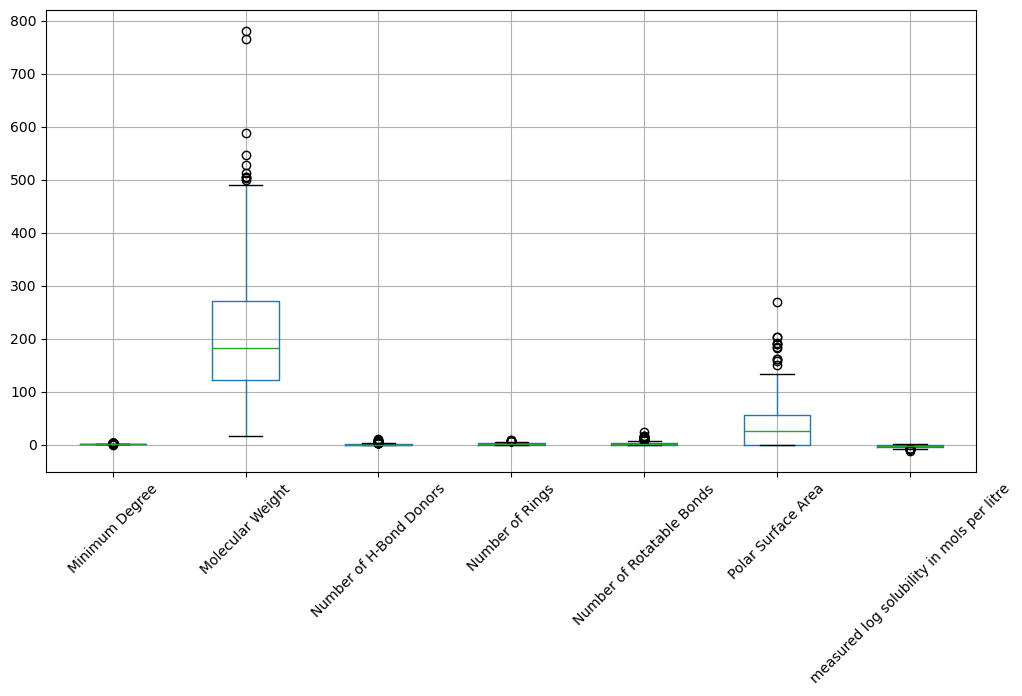

In [55]:
df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

## Feature selection

In [15]:
# Features (independent variables)
X = df.drop(columns=["measured log solubility in mols per litre"])

# Target (dependent variable)
y = df["measured log solubility in mols per litre"]

### Train-Test Split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [57]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(892, 6)
(224, 6)
(892,)
(224,)


### Create the model

In [31]:
model = LinearRegression()

### Model training

In [58]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-0.63,-0.01, 0.08,-0.38,-0.13, 0.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Minimum Degree','Molecular Weight','Number of H-Bond Donors', 'Number of Rings','Number of Rotatable Bonds','Polar Surface Area']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.04993
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


### Model prediction

In [63]:
y_pred = model.predict(X_test)

### Compare results

In [64]:
results = pd.DataFrame({
    "Actual" : y_test,
    "predicted" : y_pred
})

In [61]:
results.head(20)

,Actual,predicted
1001,-1.920,-2.639274
101,-5.430,-4.175541
488,-2.840,-4.553341
868,0.510,-2.145889
1086,-3.590,-2.805889
798,-0.910,-1.772980
528,-2.400,-1.828553
1005,-2.540,-2.832740
128,0.760,-2.258270
1082,0.940,-1.418745


### Evaluating the model

In [62]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.8919399132617313
MSE : 1.3890918694412928
RMSE: 1.1785974161864148
R²  : 0.7020356565200314
